# 08 — EDA Blocco 4: Reati con arma da fuoco

**Fase PACE**: Analyze  
**Obiettivo**: analizzare la distribuzione e il trend dei reati commessi 
con arma da fuoco, e il profilo demografico delle vittime coinvolte.

**Input**: `data/processed/crimes_features.parquet`

**Domande a cui rispondiamo**:
- Q4.1 — Distribuzione e trend dei reati con arma da fuoco per area LAPD
- Q4.2 — Profilo demografico delle vittime nei reati con arma da fuoco

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_info_columns', 200)

df = pd.read_parquet('../../data/processed/crimes_features.parquet')
df.head()

,DR_NO,Date Rptd,DATE OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,Mocodes,Vict Age,Vict Sex,Vict Descent,Premis Cd,Premis Desc,Weapon Used Cd,Weapon Desc,Status,Status Desc,Crm Cd 1,LOCATION,LAT,LON,hour_occ,year,month,day_of_week,hour_bins,age_group,crime_category,report_delay,is_domestic
0,1307355,2010-02-20,2010-02-20,13,Newton,1385,2,900,VIOLATION OF COURT ORDER,0913 1814 2000,48.0,M,H,501.0,SINGLE FAMILY DWELLING,0.0,No Weapon,AA,Adult Arrest,900.0,300 E GAGE AV,33.9825,-118.2695,13,2010,2,Saturday,Afternoon,Adult,person,0,False
1,11401303,2010-09-13,2010-09-12,14,Pacific,1485,2,740,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",0329,NaN,M,W,101.0,STREET,0.0,No Weapon,IC,Invest Cont,740.0,SEPULVEDA BL,33.9599,-118.3962,0,2010,9,Sunday,Night,NaN,property,1,False
2,70309629,2010-08-09,2010-08-09,13,Newton,1324,2,946,OTHER MISCELLANEOUS CRIME,0344,NaN,M,H,103.0,ALLEY,0.0,No Weapon,IC,Invest Cont,946.0,1300 E 21ST ST,34.0224,-118.2524,15,2010,8,Monday,Afternoon,NaN,other,0,False
3,90631215,2010-01-05,2010-01-05,6,Hollywood,646,2,900,VIOLATION OF COURT ORDER,1100 0400 1402,47.0,F,W,101.0,STREET,102.0,HAND GUN,IC,Invest Cont,900.0,CAHUENGA BL,34.1016,-118.3295,1,2010,1,Tuesday,Night,Adult,person,0,False
4,100100501,2010-01-03,2010-01-02,1,Central,176,1,122,"RAPE, ATTEMPTED",0400,47.0,F,H,103.0,ALLEY,400.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",IC,Invest Cont,122.0,8TH ST,34.0387,-118.2488,21,2010,1,Saturday,Late Night,Adult,person,1,False


## 2. Q4.1 — Distribuzione e trend reati con arma da fuoco

Analizziamo i reati commessi con arma da fuoco utilizzando la colonna 
`Weapon Desc`. Identifichiamo il volume complessivo, la distribuzione 
per area LAPD e il trend anno per anno.

**Nota**: i reati senza arma sono codificati come "No Weapon" (valore 
assegnato in fase di cleaning ai record con `Weapon Desc` nullo). 
Li escludiamo dal filtro per concentrarci sui reati con arma da fuoco.

In [5]:
q41_df = df[['AREA NAME','Weapon Desc','year']].copy()
print(q41_df.head(10))

   AREA NAME                                     Weapon Desc  year
0     Newton                                       No Weapon  2010
1    Pacific                                       No Weapon  2010
2     Newton                                       No Weapon  2010
3  Hollywood                                        HAND GUN  2010
4    Central  STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)  2010
5    Central                                       No Weapon  2010
6    Central                                       No Weapon  2010
7    Central                     UNKNOWN WEAPON/OTHER WEAPON  2010
8    Central  STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)  2010
9    Central                                       No Weapon  2010


In [6]:
q41_df['Weapon Desc'].unique()

array(['No Weapon', 'HAND GUN',
       'STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)',
       'UNKNOWN WEAPON/OTHER WEAPON', 'VERBAL THREAT', 'SIMULATED GUN',
       'FOLDING KNIFE', 'OTHER KNIFE', 'MACE/PEPPER SPRAY', 'STICK',
       'UNKNOWN FIREARM', 'SWITCH BLADE',
       'KNIFE WITH BLADE 6INCHES OR LESS', 'BOARD', 'BLUNT INSTRUMENT',
       'SEMI-AUTOMATIC PISTOL', 'VEHICLE', 'OTHER CUTTING INSTRUMENT',
       'SCISSORS', 'BOTTLE', 'KNIFE WITH BLADE OVER 6 INCHES IN LENGTH',
       'BELT FLAILING INSTRUMENT/CHAIN',
       'AUTOMATIC WEAPON/SUB-MACHINE GUN', 'CLUB/BAT', 'BRASS KNUCKLES',
       'KITCHEN KNIFE', 'AIR PISTOL/REVOLVER/RIFLE/BB GUN', 'SCREWDRIVER',
       'FIRE', 'STUN GUN', 'RIFLE', 'RAZOR BLADE', 'DIRK/DAGGER',
       'CAUSTIC CHEMICAL/POISON', 'SHOTGUN', 'ICE PICK', 'BOMB THREAT',
       'ROCK/THROWN OBJECT', 'REVOLVER', 'OTHER FIREARM', 'DEMAND NOTE',
       'BOWIE KNIFE', 'HECKLER & KOCH 93 SEMIAUTOMATIC ASSAULT RIFLE',
       'SCALDING LIQUID', 'ROPE/LIGATURE'

In [7]:
firearm_list = [
    'HAND GUN',
    'UNKNOWN FIREARM',
    'SEMI-AUTOMATIC PISTOL',
    'AUTOMATIC WEAPON/SUB-MACHINE GUN',
    'RIFLE',
    'SHOTGUN',
    'REVOLVER',
    'OTHER FIREARM',
    'HECKLER & KOCH 93 SEMIAUTOMATIC ASSAULT RIFLE',
    'UZI SEMIAUTOMATIC ASSAULT RIFLE',
    'SAWED OFF RIFLE/SHOTGUN',
    'HECKLER & KOCH 91 SEMIAUTOMATIC ASSAULT RIFLE',
    'ASSAULT WEAPON/UZI/AK47/ETC',
    'SEMI-AUTOMATIC RIFLE',
    'STARTER PISTOL/REVOLVER',
    'UNK TYPE SEMIAUTOMATIC ASSAULT RIFLE',
    'MAC-10 SEMIAUTOMATIC ASSAULT WEAPON',
    'RELIC FIREARM',
    'MAC-11 SEMIAUTOMATIC ASSAULT WEAPON',
    'ANTIQUE FIREARM',
    'M-14 SEMIAUTOMATIC ASSAULT RIFLE',
    'M1-1 SEMIAUTOMATIC ASSAULT RIFLE',
    'SIMULATED GUN',
    'AIR PISTOL/REVOLVER/RIFLE/BB GUN',
    'TOY GUN'
]

q41_df_filtered = q41_df[q41_df['Weapon Desc'].isin(firearm_list)].copy()
print(q41_df_filtered.head(10))

     AREA NAME            Weapon Desc  year
3    Hollywood               HAND GUN  2010
55     Central          SIMULATED GUN  2010
94     Central               HAND GUN  2010
103    Central               HAND GUN  2010
112    Central        UNKNOWN FIREARM  2010
187    Central        UNKNOWN FIREARM  2010
240    Central  SEMI-AUTOMATIC PISTOL  2010
264    Central          SIMULATED GUN  2010
288    Central               HAND GUN  2010
293    Central               HAND GUN  2010


In [18]:
q41_df_area_volume = (
    q41_df_filtered
    .groupby(['AREA NAME'], as_index=False)
    .agg(count = ('AREA NAME','count'))
).copy()

q41_df_area_volume.sort_values(by='count', ascending = False, inplace=True)

print(q41_df_area_volume.shape)
print('==========')
print(q41_df_area_volume.head(10))

(21, 2)
      AREA NAME  count
0   77th Street  17036
14    Southeast  12222
9        Newton   9879
15    Southwest   8938
5    Hollenbeck   6223
4        Harbor   5640
13      Rampart   5131
7       Mission   4254
11      Olympic   4157
10    Northeast   3933


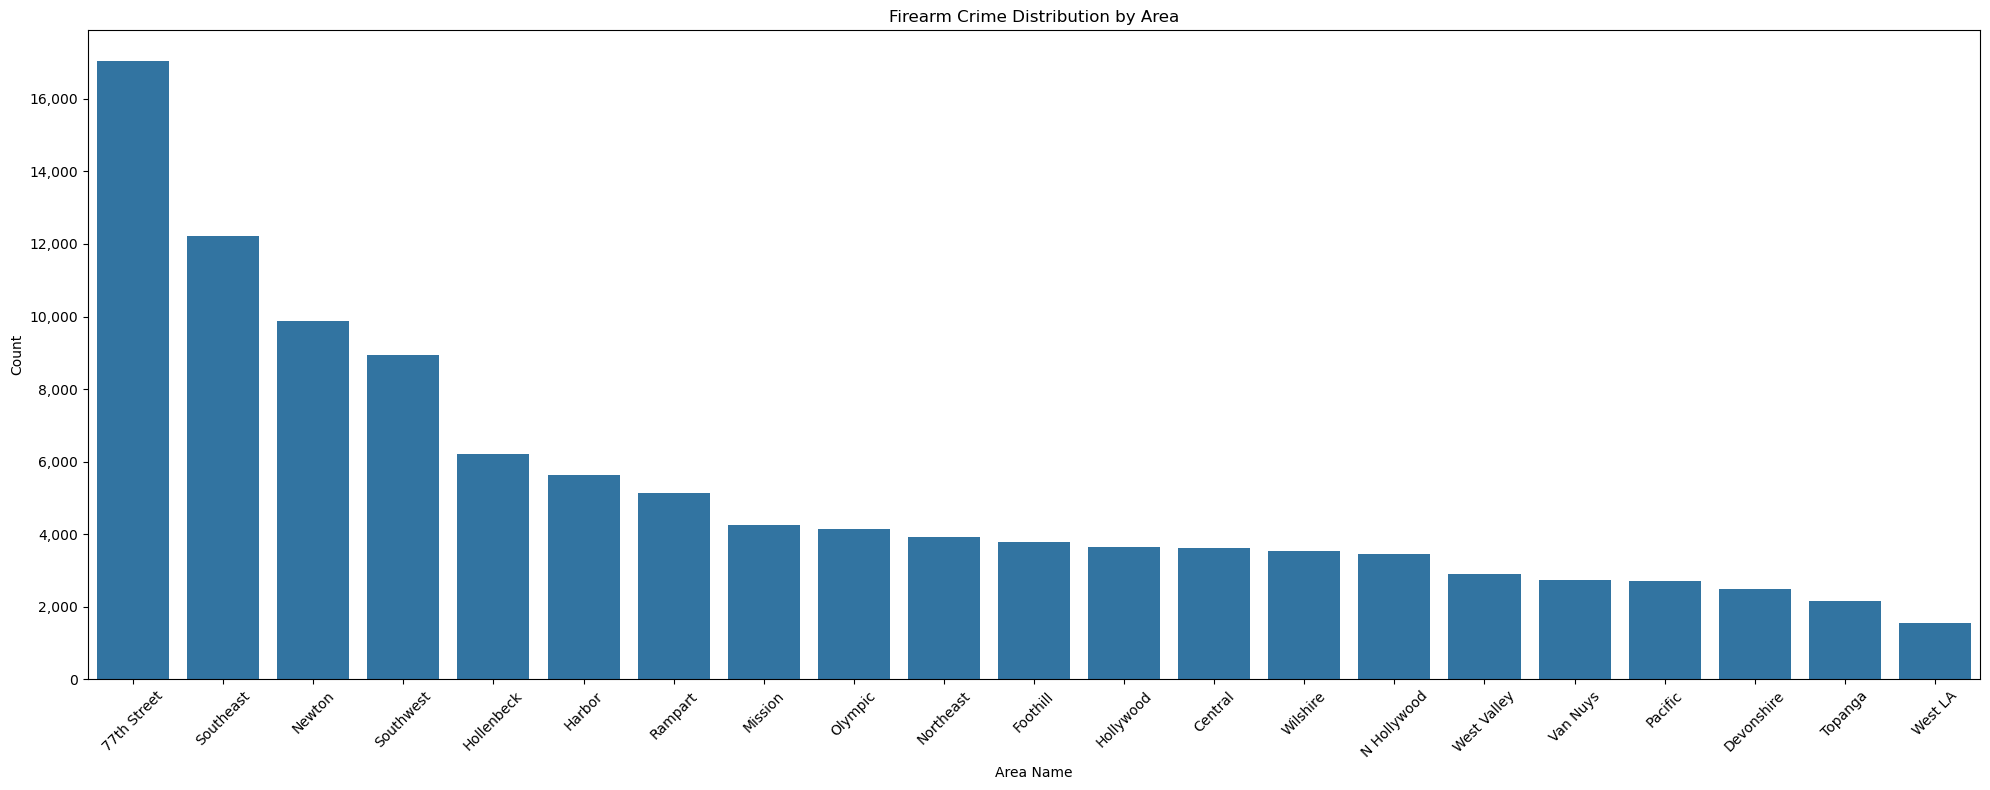

In [19]:
fig, ax = plt.subplots(figsize=(20, 8))

sns.barplot(
    data=q41_df_area_volume,
    x='AREA NAME',
    y='count',
    ax=ax
)

ax.set_title('Firearm Crime Distribution by Area')
ax.set_xlabel('Area Name')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('../../outputs/08_eda_block4/23_barplot_firearm_crimes_by_area.png', dpi=150, bbox_inches='tight')
plt.show()

### Osservazioni Q4.1 — Distribuzione reati con arma da fuoco per area LAPD

**Nota metodologica**: l'analisi include 25 categorie di armi. Tre di esse 
non sono armi da fuoco reali ma vengono incluse perché utilizzate per far 
percepire alla vittima una minaccia armata:
- **SIMULATED GUN**: pistola simulata
- **AIR PISTOL/REVOLVER/RIFLE/BB GUN**: arma ad aria compressa
- **TOY GUN**: pistola giocattolo

**Aree con maggior volume di reati con arma da fuoco**:
- 77th Street: 17.036 (dato dominante, distacco netto dal resto)
- Southeast: 12.121
- Newton: 9.879
- Southwest: 8.908

**Aree con minor volume**:
- West LA: 1.489
- Topanga: 2.134
- Pacific: 2.712
- Devonshire: 2.478

**Pattern geografico**: le quattro aree con più reati con arma da fuoco 
(77th Street, Southeast, Newton, Southwest) coincidono con le stesse aree 
che dominano la distribuzione dei reati domestici nel Blocco 3. Emerge una 
sovrapposizione geografica significativa tra violenza armata e violenza 
domestica nelle stesse zone di Los Angeles.

In [34]:
q41_df_weapon_volume = (
    q41_df_filtered
    .groupby(['Weapon Desc'], as_index = False)
    .agg(count = ('Weapon Desc', 'count'))
    .sort_values(by='count', ascending = False)
).copy()

print(q41_df_weapon_volume.head(50))

                                      Weapon Desc  count
4                                        HAND GUN  53523
16                          SEMI-AUTOMATIC PISTOL  19917
23                                UNKNOWN FIREARM  14302
13                                       REVOLVER   6632
19                                  SIMULATED GUN   4744
0                AIR PISTOL/REVOLVER/RIFLE/BB GUN   4451
11                                  OTHER FIREARM   1826
18                                        SHOTGUN   1490
14                                          RIFLE   1343
21                                        TOY GUN    461
6   HECKLER & KOCH 93 SEMIAUTOMATIC ASSAULT RIFLE    245
2                     ASSAULT WEAPON/UZI/AK47/ETC    244
3                AUTOMATIC WEAPON/SUB-MACHINE GUN    193
15                        SAWED OFF RIFLE/SHOTGUN    179
17                           SEMI-AUTOMATIC RIFLE    148
20                        STARTER PISTOL/REVOLVER    147
22           UNK TYPE SEMIAUTOM

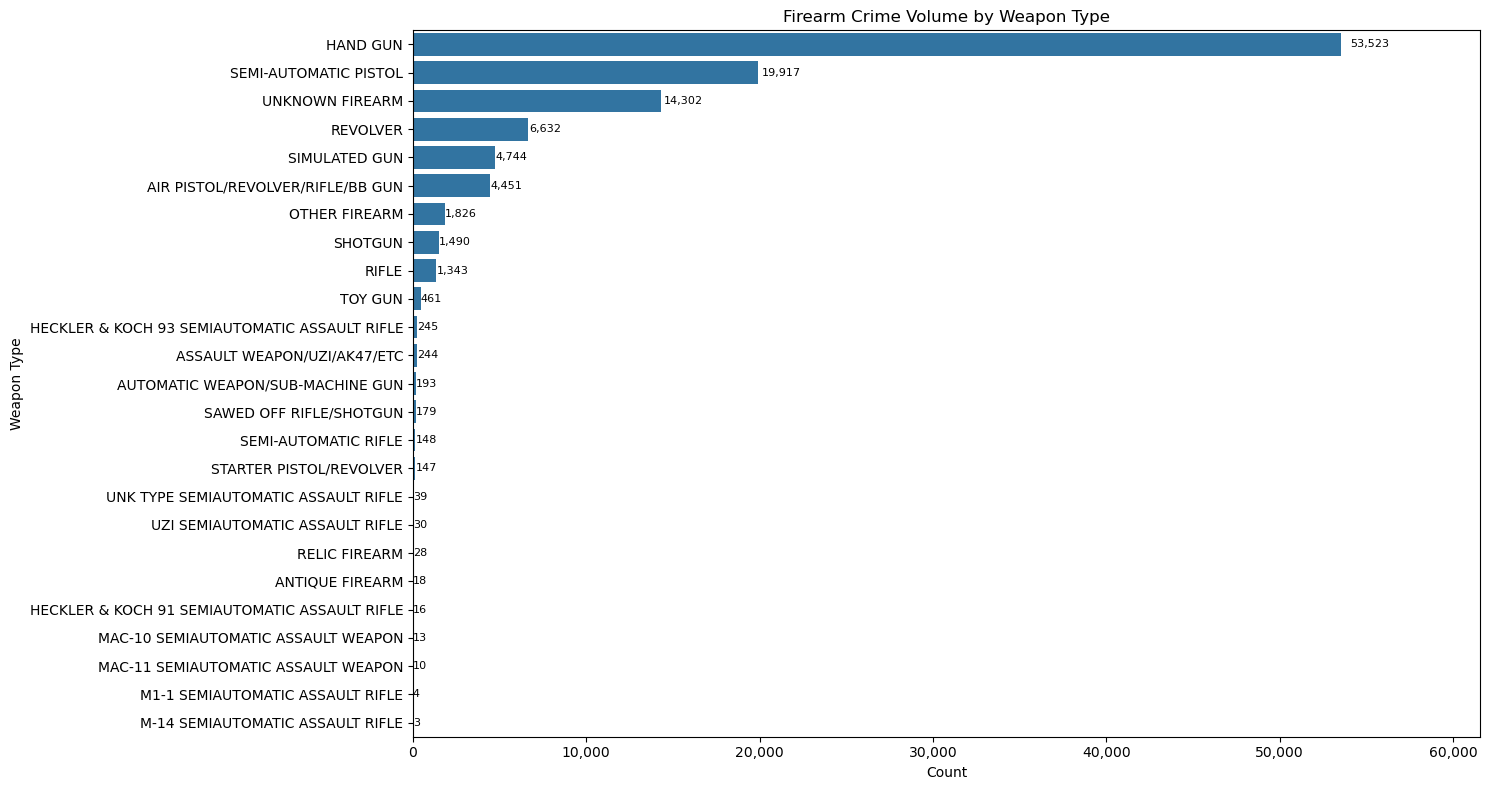

In [33]:
fig, ax = plt.subplots(figsize=(15, 8))

bars = sns.barplot(
    data=q41_df_weapon_volume,
    y='Weapon Desc',
    x='count',
    ax=ax
)

for bar, value in zip(ax.patches, q41_df_weapon_volume['count']):
    ax.text(
        bar.get_width() + bar.get_width() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{int(value):,}',
        va='center', ha='left',
        fontsize=8
    )

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.margins(x=0.15)

ax.set_title('Firearm Crime Volume by Weapon Type')
ax.set_xlabel('Count')
ax.set_ylabel('Weapon Type')

plt.tight_layout()
plt.savefig('../../outputs/08_eda_block4/24_barh_firearm_volume_by_weapon.png', dpi=150, bbox_inches='tight')
plt.show()

### Osservazioni Q4.1 — Volume per tipo di arma da fuoco

**Top 4 armi più utilizzate** (circa 81% del totale):
- **Hand Gun**: 53.523 (~46%) — arma dominante, facile da reperire e 
  da occultare
- **Semi-Automatic Pistol**: 19.917 (~17%)
- **Unknown Firearm**: 14.302 (~12%)
- **Revolver**: 6.632 (~6%)

**Categorie non-arma da fuoco reale**: Simulated Gun (4.744) e 
Air Pistol/BB Gun (4.451) hanno volumi significativi — quasi 10.000 
casi complessivi. Confermano che la minaccia percepita è spesso 
sufficiente per commettere un crimine senza un'arma reale.

**Armi d'assalto**: tutte le categorie di assault rifle e armi 
automatiche (Heckler & Koch, UZI, MAC-10, MAC-11, AK47, M-14, M1-1) 
mostrano valori irrisori individualmente. La loro presenza nel dataset, 
sebbene marginale, è comunque un dato rilevante per la sicurezza pubblica.

**Pattern generale**: il dataset conferma che i reati con arma da fuoco 
utilizzano prevalentemente armi comuni, compatte e facili da reperire. 
Le armi più sofisticate e difficili da occultare (fucili d'assalto, 
armi automatiche) sono quasi assenti.